In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = DATA_DIR
BASE_PATH = PROJECT_ROOT / 'bases' / 'grupo1' / 'bitcoin.xlsx'

# 02 — Limpeza e Preparação dos Dados
**Grupo 1 | Séries Temporais**

Este notebook realiza a limpeza, regularização temporal e preparação da base Bitcoin para uso nos modelos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

## 1. Carregamento da Base Bruta

In [3]:
df_raw = pd.read_excel(BASE_PATH)

# Converter timestamps Unix ms → datetime
for col in ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']:
    df_raw[col] = pd.to_datetime(df_raw[col], unit='ms')

# Renomear e normalizar a data de abertura como índice
df_raw = df_raw.rename(columns={'timeOpen': 'date'})
df_raw['date'] = df_raw['date'].dt.normalize()
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape bruto: {df_raw.shape}')
print(f'Período    : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
df_raw[['date','priceOpen','priceHigh','priceLow','priceClose','volume']].head()

Shape bruto: (2920, 9)
Período    : 2018-08-22 → 2026-09-11


,date,priceOpen,priceHigh,priceLow,priceClose,volume
0,2018-08-22,6486.25,6816.79,6310.11,6376.71,4.668110e+09
1,2018-08-23,6371.34,6546.54,6371.34,6534.88,3.426180e+09
2,2018-08-24,6551.52,6719.96,6498.64,6719.96,4.097820e+09
3,2018-08-25,6719.95,6789.63,6700.96,6763.19,3.312600e+09
4,2018-08-26,6754.64,6774.75,6620.75,6707.26,3.295500e+09


## 2. Decisões de Limpeza

Com base na documentação (notebook 01), as seguintes decisões foram tomadas:

| Problema | Decisão |
|----------|---------|
| Colunas de timestamp (timeClose, timeHigh, timeLow) | Descartadas — irrelevantes para modelagem |
| 5 lacunas temporais (até 9 dias) em 2023 | Reindexação para frequência diária + interpolação linear |
| Valores ausentes | Nenhum presente na base original |
| Duplicatas | Nenhuma presente na base original |
| Outliers | Mantidos — volatilidade é característica intrínseca de criptomoedas |
| Escala do volume | Mantida em USD (não normalizada aqui — normalização ocorre no FE) |

In [4]:
# Descartar colunas de timestamp auxiliares
cols_manter = ['date', 'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume']
df = df_raw[cols_manter].copy()
print(f'Colunas mantidas: {df.columns.tolist()}')

Colunas mantidas: ['date', 'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume']


## 3. Regularização da Frequência Diária

Bitcoin é negociado 24/7, mas a base possui 5 lacunas. Vamos reindexar para uma grade diária completa e interpolar.

In [5]:
# Identificar lacunas antes do tratamento
df_tmp = df.set_index('date')
data_range_completo = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
datas_faltantes = data_range_completo.difference(df['date'])
print(f'Datas faltantes na série: {len(datas_faltantes)}')
if len(datas_faltantes) > 0:
    print(datas_faltantes.tolist())

Datas faltantes na série: 23
[Timestamp('2023-09-18 00:00:00'), Timestamp('2023-09-19 00:00:00'), Timestamp('2023-09-20 00:00:00'), Timestamp('2023-09-21 00:00:00'), Timestamp('2023-09-23 00:00:00'), Timestamp('2023-11-02 00:00:00'), Timestamp('2023-11-03 00:00:00'), Timestamp('2023-11-06 00:00:00'), Timestamp('2023-11-07 00:00:00'), Timestamp('2023-11-08 00:00:00'), Timestamp('2023-11-09 00:00:00'), Timestamp('2023-11-10 00:00:00'), Timestamp('2023-11-11 00:00:00'), Timestamp('2023-11-12 00:00:00'), Timestamp('2023-11-13 00:00:00'), Timestamp('2023-12-01 00:00:00'), Timestamp('2023-12-02 00:00:00'), Timestamp('2023-12-03 00:00:00'), Timestamp('2023-12-04 00:00:00'), Timestamp('2023-12-05 00:00:00'), Timestamp('2023-12-06 00:00:00'), Timestamp('2023-12-07 00:00:00'), Timestamp('2023-12-08 00:00:00')]


In [6]:
# Reindexar para frequência diária completa
df = df.set_index('date')
df = df.reindex(data_range_completo)
df.index.name = 'date'

print(f'Linhas introduzidas por reindexação: {df.isnull().any(axis=1).sum()}')
print(f'Shape após reindexação: {df.shape}')

# Interpolação linear para preencher as lacunas
df = df.interpolate(method='linear')

# Verificação
print(f'Nulos restantes após interpolação: {df.isnull().sum().sum()}')
df = df.reset_index()
print(f'Shape final limpo: {df.shape}')
df.head()

Linhas introduzidas por reindexação: 23
Shape após reindexação: (2943, 5)
Nulos restantes após interpolação: 0
Shape final limpo: (2943, 6)


,date,priceOpen,priceHigh,priceLow,priceClose,volume
0,2018-08-22,6486.25,6816.79,6310.11,6376.71,4.668110e+09
1,2018-08-23,6371.34,6546.54,6371.34,6534.88,3.426180e+09
2,2018-08-24,6551.52,6719.96,6498.64,6719.96,4.097820e+09
3,2018-08-25,6719.95,6789.63,6700.96,6763.19,3.312600e+09
4,2018-08-26,6754.64,6774.75,6620.75,6707.26,3.295500e+09


## 4. Transformações Adicionais

In [7]:
# Transformação logarítmica do preço (útil para análise de retornos e estabilização de variância)
df['log_priceClose'] = np.log(df['priceClose'])
df['log_volume']     = np.log(df['volume'])

# Retorno diário logarítmico (% de variação)
df['daily_return'] = df['priceClose'].pct_change() * 100

# Amplitude diária (High - Low) — proxy de volatilidade do dia
df['daily_range'] = df['priceHigh'] - df['priceLow']

print('Novas colunas criadas:')
print(['log_priceClose', 'log_volume', 'daily_return', 'daily_range'])
df[['date','priceClose','log_priceClose','daily_return','daily_range']].head(10)

Novas colunas criadas:
['log_priceClose', 'log_volume', 'daily_return', 'daily_range']


,date,priceClose,log_priceClose,daily_return,daily_range
0,2018-08-22,6376.71,8.760408,NaN,506.68
1,2018-08-23,6534.88,8.784909,2.480433,175.20
2,2018-08-24,6719.96,8.812837,2.832187,221.32
3,2018-08-25,6763.19,8.819250,0.643307,88.67
4,2018-08-26,6707.26,8.810946,-0.826977,154.00
5,2018-08-27,6884.64,8.837048,2.644597,194.93
6,2018-08-28,7096.28,8.867326,3.074090,227.22
7,2018-08-29,7047.16,8.860380,-0.692194,142.48
8,2018-08-30,6978.23,8.850551,-0.978125,238.00
9,2018-08-31,7037.58,8.859020,0.850502,137.01


## 5. Visualizações Pós-Limpeza

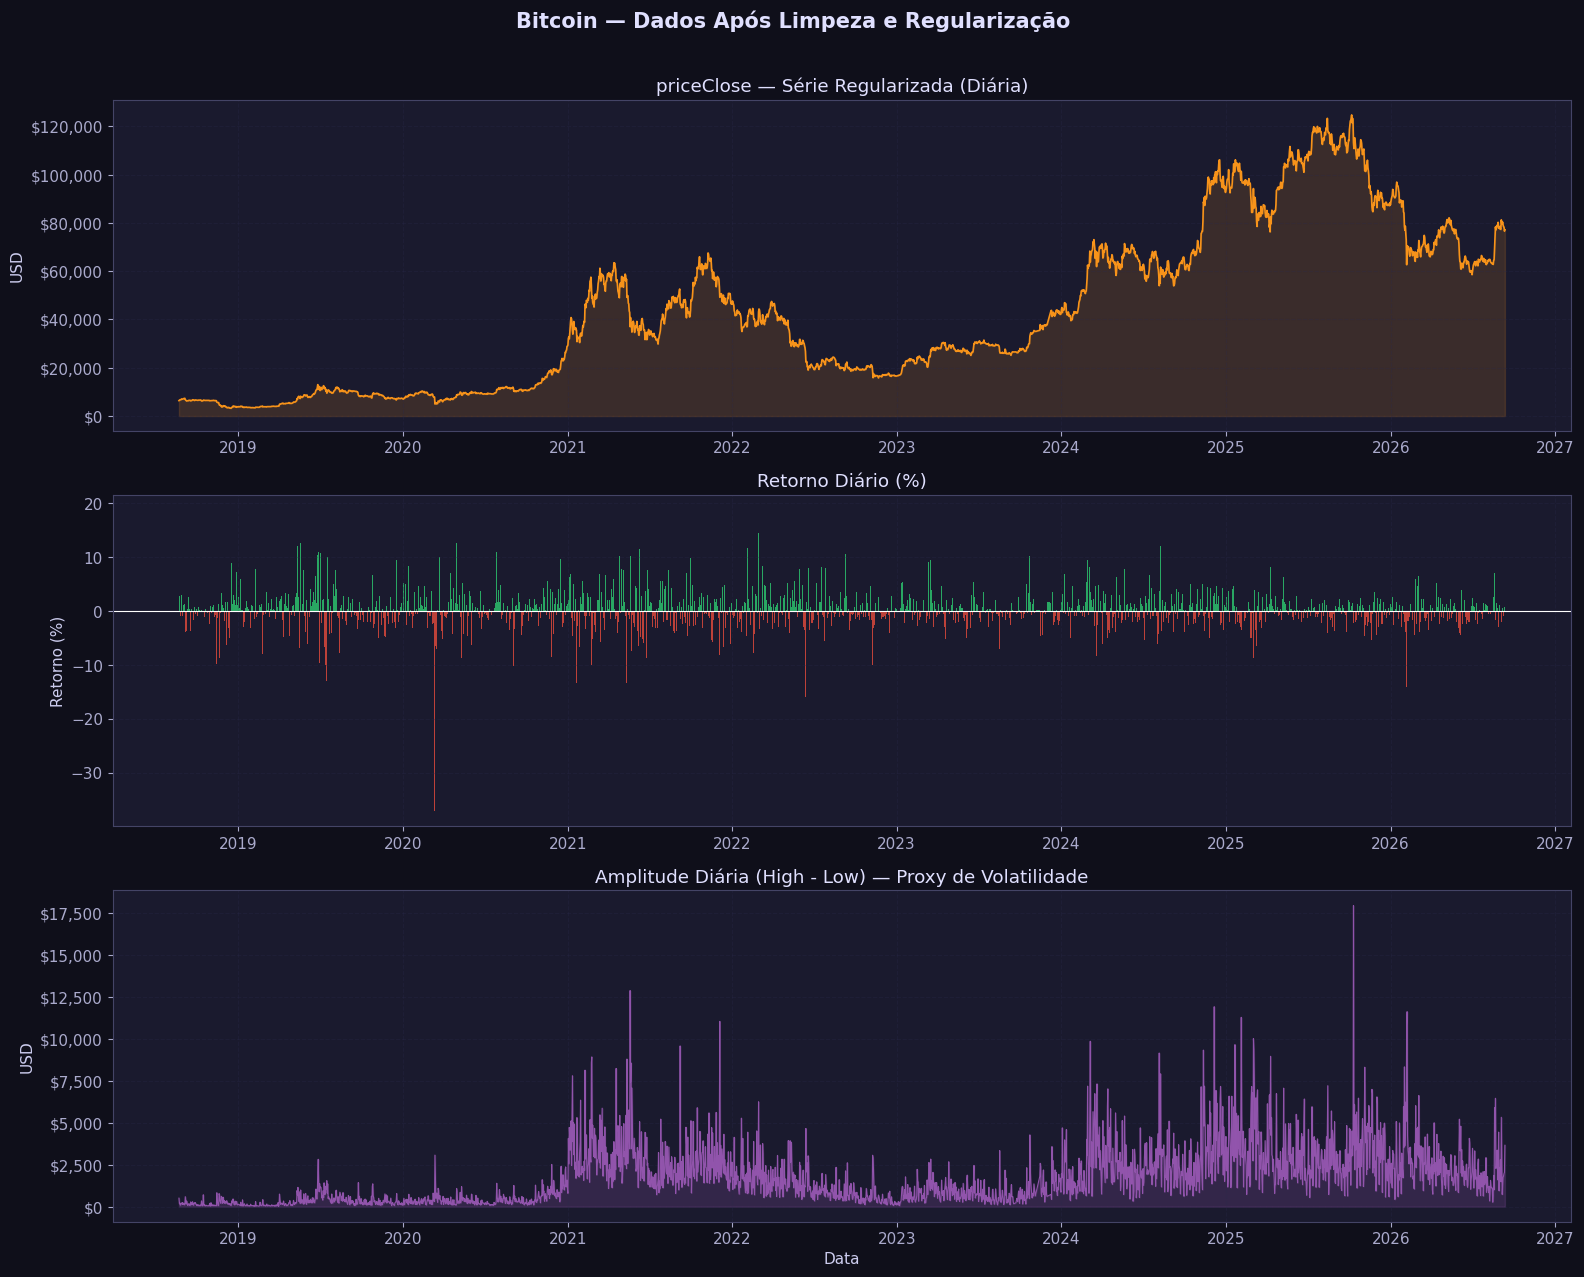

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0f0f1a')
fig.suptitle('Bitcoin — Dados Após Limpeza e Regularização', 
             fontsize=15, fontweight='bold', color='#e0e0ff', y=0.98)

# Série original limpa
axes[0].plot(df['date'], df['priceClose'], color='#f7931a', linewidth=1.2)
axes[0].fill_between(df['date'], df['priceClose'], alpha=0.15, color='#f7931a')
axes[0].set_title('priceClose — Série Regularizada (Diária)', color='#e0e0ff')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# Retorno diário
cores_ret = ['#e74c3c' if r < 0 else '#2ecc71' for r in df['daily_return'].fillna(0)]
axes[1].bar(df['date'], df['daily_return'], color=cores_ret, alpha=0.8, width=1)
axes[1].axhline(0, color='#ffffff', linewidth=0.8)
axes[1].set_title('Retorno Diário (%)', color='#e0e0ff')
axes[1].set_ylabel('Retorno (%)')
axes[1].grid(True, alpha=0.3)

# Amplitude diária (volatilidade)
axes[2].plot(df['date'], df['daily_range'], color='#9b59b6', linewidth=0.8, alpha=0.9)
axes[2].fill_between(df['date'], df['daily_range'], alpha=0.2, color='#9b59b6')
axes[2].set_title('Amplitude Diária (High - Low) — Proxy de Volatilidade', color='#e0e0ff')
axes[2].set_ylabel('USD')
axes[2].set_xlabel('Data')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'plot_04_dados_limpos.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Divisão Treino / Teste e Exportação

In [9]:
n = len(df)
n_train = int(n * TRAIN_RATIO)
n_test  = n - n_train
data_corte = df.iloc[n_train]['date']

df_train = df.iloc[:n_train].copy()
df_test  = df.iloc[n_train:].copy()

print('=== Divisão Final ===')
print(f'Total: {n} observações')
print(f'Treino: {n_train} | {df_train["date"].min().date()} → {df_train["date"].max().date()}')
print(f'Teste : {n_test}  | {df_test["date"].min().date()} → {df_test["date"].max().date()}')
print(f'Corte : {data_corte.date()}')

=== Divisão Final ===
Total: 2943 observações
Treino: 2060 | 2018-08-22 → 2024-04-11
Teste : 883  | 2024-04-12 → 2026-09-11
Corte : 2024-04-12


In [10]:
# Exportar base limpa para uso nos próximos notebooks
df.to_csv(OUTPUT_DIR / 'bitcoin_limpo.csv', index=False)
df_train.to_csv(OUTPUT_DIR / 'bitcoin_train.csv', index=False)
df_test.to_csv(OUTPUT_DIR / 'bitcoin_test.csv', index=False)

print('Arquivos exportados:')
print('  bitcoin_limpo.csv — base completa limpa')
print('  bitcoin_train.csv — conjunto de treino (70%)')
print('  bitcoin_test.csv  — conjunto de teste (30%)')

Arquivos exportados:
  bitcoin_limpo.csv — base completa limpa
  bitcoin_train.csv — conjunto de treino (70%)
  bitcoin_test.csv  — conjunto de teste (30%)


## 7. Resumo das Decisões de Limpeza

| Etapa | Ação | Justificativa |
|-------|------|---------------|
| Colunas descartadas | `timeClose`, `timeHigh`, `timeLow` | Irrelevantes para modelagem |
| Regularização | Reindexação para grade diária completa | 5 lacunas identificadas em 2023 |
| Preenchimento de lacunas | Interpolação linear | Variações entre dias próximos são suaves |
| Transformação log | `log_priceClose`, `log_volume` | Estabiliza variância, útil para análise |
| Retorno diário | `daily_return` = pct_change × 100 | Proxy de rentabilidade |
| Amplitude diária | `daily_range` = High − Low | Proxy de volatilidade intra-day |
| Outliers | Mantidos | Volatilidade intrínseca de criptomoedas |
| Nulos após limpeza | 0 | ✅ |

**Próximo passo:** `03_feature_engineering.ipynb`